In [3]:
import pandas as pd
import glob
import os
import numpy as np

Looking in: C:\Users\liang\Documents\GitHub\conformalHDC\experiments_real\results\odor_decoding
Found 20 files matching pattern '*beta*.csv'

 VANILLA ACCURACY (Higher is better)


rat_id,0,1,2,3,4,AVERAGE
beta,,,,,,
0.3,0.4596,0.6291,0.6070,0.5935,0.7369,0.6052
0.5,0.4546,0.6183,0.5954,0.5630,0.7213,0.5905
0.7,0.4479,0.5920,0.5469,0.5170,0.6984,0.5604
1.0,0.4189,0.5310,0.4600,0.4568,0.6306,0.4994


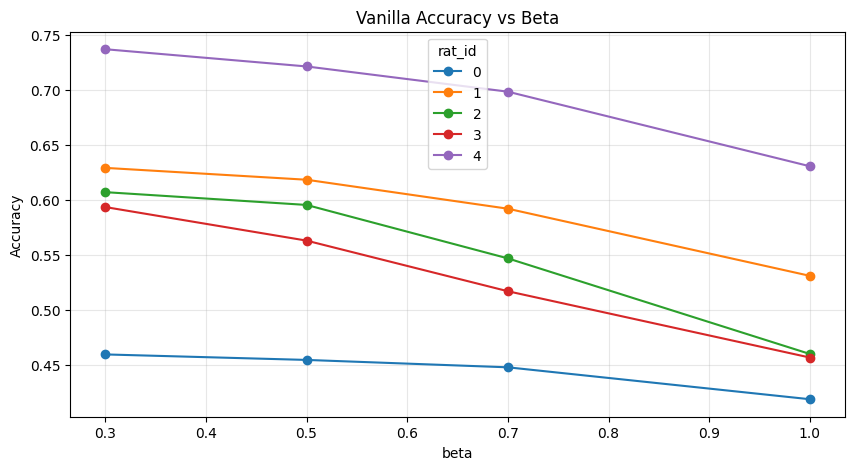


 SET SIZE (Score Type: Discount)


rat_id,0,1,2,3,4,AVERAGE
beta,,,,,,
0.3,2.2942,1.6995,1.7425,1.7373,1.2075,1.7362
0.5,2.3385,1.7409,1.7801,1.7892,1.2208,1.7739
0.7,2.3782,1.8984,1.9270,1.9091,1.2942,1.8814
1.0,2.5566,2.3047,2.2391,2.2426,1.6274,2.1941


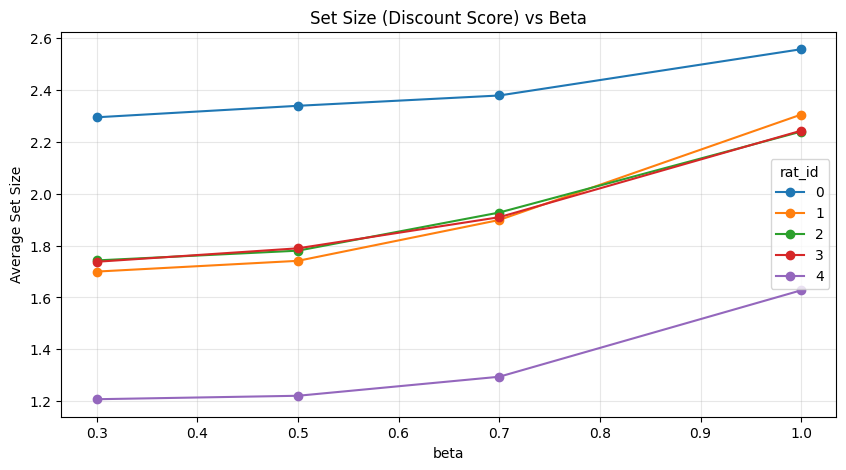

In [7]:
results_path = "../experiments_real/results/odor_decoding"

# OR, if your notebook is inside the folder with the csv files:
# results_path = "." 
# ==========================================

# 2. Load Data
search_pattern = os.path.join(results_path, "*beta*.csv")
files = glob.glob(search_pattern)

print(f"Looking in: {os.path.abspath(results_path)}")
print(f"Found {len(files)} files matching pattern '*beta*.csv'")

if len(files) > 0:
    dfs = []
    for f in files:
        try:
            df = pd.read_csv(f)
            dfs.append(df)
        except Exception as e:
            print(f"Skipping {os.path.basename(f)}: {e}")

    full_df = pd.concat(dfs, ignore_index=True)

    # ---------------------------------------------------------
    # PART 1: Vanilla Accuracy vs Beta
    # ---------------------------------------------------------
    print("\n" + "="*60)
    print(" VANILLA ACCURACY (Higher is better)")
    print("="*60)
    
    # Filter for method='vanilla' (Standard HDC without conformal)
    vanilla_df = full_df[full_df['method'] == 'vanilla']
    
    if not vanilla_df.empty:
        # Pivot: Rows=Beta, Cols=Rat_ID
        acc_pivot = vanilla_df.pivot_table(
            index='beta', 
            columns='rat_id', 
            values='point_acc', 
            aggfunc='mean'
        )
        acc_pivot['AVERAGE'] = acc_pivot.mean(axis=1)
        
        display(acc_pivot.round(4))
        
        # Plot Accuracy
        try:
            ax = acc_pivot.drop(columns=['AVERAGE']).plot(
                kind='line', marker='o', figsize=(10, 5), 
                title="Vanilla Accuracy vs Beta"
            )
            ax.set_ylabel("Accuracy")
            ax.grid(True, alpha=0.3)
            plt.show()
        except: pass
    else:
        print("No vanilla accuracy data found.")

    # ---------------------------------------------------------
    # PART 2: Set Size (Discount Score Only)
    # ---------------------------------------------------------
    print("\n" + "="*60)
    print(" SET SIZE (Score Type: Discount)")
    print("="*60)
    
    # Filter for set_valued experiment AND score_type='discount'
    discount_df = full_df[
        (full_df['exp'] == 'set_valued') & 
        (full_df['score_type'] == 'ratio')
    ]
    
    if not discount_df.empty:
        # Pivot: Rows=Beta, Cols=Rat_ID
        set_pivot = discount_df.pivot_table(
            index='beta', 
            columns='rat_id', 
            values='set_size', 
            aggfunc='mean'
        )
        set_pivot['AVERAGE'] = set_pivot.mean(axis=1)
        
        display(set_pivot.round(4))
        
        # Plot Set Size
        try:
            ax = set_pivot.drop(columns=['AVERAGE']).plot(
                kind='line', marker='o', figsize=(10, 5), 
                title="Set Size (Discount Score) vs Beta"
            )
            ax.set_ylabel("Average Set Size")
            ax.grid(True, alpha=0.3)
            plt.show()
        except: pass
    else:
        print("No set-valued data found for score_type='discount'.")

else:
    print("No files found! Please check the 'results_path' variable.")

In [4]:
analyze_results()

No result files found.
